# Week 18: From next-character likelihood to causal wake decoding

Why must parallel next-token training hide future inputs, even when deployment is autoregressive?

**Prerequisites:** Week 17 mechanics; cross-entropy and MSE. This is a required language-model laboratory.

Allow 120 minutes plus the written analysis. Instructor solution edition.

In [1]:
from pathlib import Path
import sys, tempfile, json
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'flowmllab/transformer_course.py').exists()),None)
if ROOT is None:
    raise RuntimeError('Extract the supplied course bundle and start Jupyter in its root; see docs/TRANSFORMER_COURSE.md for Colab upload setup.')
sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from flowmllab import transformer_course as lab
lab.seed_all(17)
cases,input_manifest=lab.load_data(ROOT)
EVIDENCE=ROOT/'results/transformer_course_v3'
# Any optional experiment must write into this disposable workspace.
workspace=tempfile.TemporaryDirectory(prefix='flowmllab-student-')
RUN_OUTPUT=Path(workspace.name)
task_status={}
print('Loaded checksummed simulated wake fields. No retained files will be rewritten.')

task_status={i:None for i in range(1,5)}


Loaded checksummed simulated wake fields. No retained files will be rewritten.


In [2]:
RUN_EXERCISES=True

## Train a small language model from scratch

Train a small character model on actual FlowMLLab documentation, with a separate document for validation. This is an instructional language model, not a pretrained LLM. Vocabulary is fitted on training documents only; unseen validation characters map to an explicit unknown token. Perplexity and generated text do not establish physical correctness.

Corpus provenance: [('data/modal_labs/README.md', 'f14f4d43254aa647eb2ebdab9f2ebe042a49b35f16bfa60dd2448e3d0a5d695b'), ('docs/RESULTS_GUIDE.md', 'e42cdf3f741f75e07cfced599e441f28c09f8b89ea26f8351e239581176a8710'), ('notebooks/week07_3/README.md', '6e611884bfed75feb41e88850fe175b7d02edc664cb372bb075c8169edbf205f'), ('notebooks/week07_4/README.md', '314df7e5450b59f55580f6271524fe93991f8527ba2db0cbdac5e1c72164696e')]
Training/validation characters: 52705 616 windows: 13171 148
Validation unknown-token fraction: 0.0


Vocabulary: 72 held-out cross-entropy: 2.679877281188965 perplexity: 14.583303540393262
Validation uses a separate course document; shared domain and short context limit generalization claims.
Sample: the sere -s, tegsinder"coront mcelopritidedion

des s/phan aboo#n a wab corealond /genchs spon, finteave


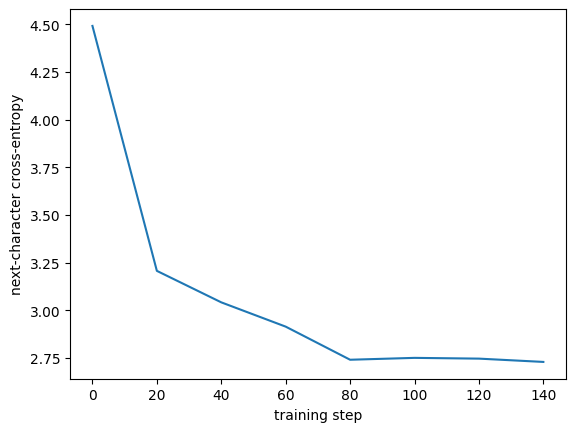

In [3]:
train_paths=[ROOT/'data/modal_labs/README.md',ROOT/'docs/RESULTS_GUIDE.md',ROOT/'notebooks/week07_3/README.md']
validation_path=ROOT/'notebooks/week07_4/README.md'
text='\n'.join(p.read_text(encoding='utf-8').lower() for p in train_paths)
validation_text=validation_path.read_text(encoding='utf-8').lower()
vocab=sorted(set(text))+['?UNK?'];stoi={c:i for i,c in enumerate(vocab)};unknown=len(vocab)-1
ids_text=np.array([stoi[c] for c in text]);validation_ids=np.array([stoi.get(c,unknown) for c in validation_text]);context=24
print('Corpus provenance:',[(p.relative_to(ROOT).as_posix(),lab.canonical_digest(p)) for p in train_paths+[validation_path]])
def text_windows(a):
    starts=np.arange(0,len(a)-context,4)
    return torch.tensor(np.stack([a[s:s+context] for s in starts])),torch.tensor(np.stack([a[s+1:s+context+1] for s in starts]))
tx,ty=text_windows(ids_text);vx,vy=text_windows(validation_ids)
print('Training/validation characters:',len(text),len(validation_text),'windows:',len(tx),len(vx))
print('Validation unknown-token fraction:',float(np.mean(validation_ids==unknown)))
language=lab.TinyLM(len(vocab),context);opt=torch.optim.Adam(language.parameters(),lr=.004)
curve=[]
for step in range(160):
    batch=torch.randint(len(tx),(32,));opt.zero_grad()
    logits=language(tx[batch]);loss=torch.nn.functional.cross_entropy(logits.reshape(-1,len(vocab)),ty[batch].reshape(-1));loss.backward();opt.step()
    if step%20==0:curve.append((step,float(loss.detach())))
with torch.no_grad():
    heldout=float(torch.nn.functional.cross_entropy(language(vx[:64]).reshape(-1,len(vocab)),vy[:64].reshape(-1)))
print('Vocabulary:',len(vocab),'held-out cross-entropy:',heldout,'perplexity:',np.exp(heldout))
print('Validation uses a separate course document; shared domain and short context limit generalization claims.')
sample=[stoi[c] for c in 'the ']
with torch.no_grad():
    for _ in range(100):
        logits=language(torch.tensor([sample[-context:]]))[:,-1]/.8
        sample.append(int(torch.multinomial(logits.softmax(-1),1)))
print('Sample:', ''.join(vocab[i] for i in sample))
plt.plot(*np.array(curve).T);plt.xlabel('training step');plt.ylabel('next-character cross-entropy');plt.show()

## Expose the causal-mask mechanism on POD tokens

Every output position predicts its next state. Perturb future inputs while holding a prefix fixed. The masked prefix must stay unchanged; the unmasked control must react. A one-block, last-token-only predictor cannot demonstrate this mechanism.

In [4]:
representation=lab.Representation.fit(cases[110]['omega'][:160],8)
z=representation.encode(cases[110]['omega']);xx,yy=lab.sequence_windows(z[:160])
decoder=lab.CausalDecoder();x=torch.tensor(xx[:3],dtype=torch.float32);changed=x.clone();changed[:,2:]+=10
with torch.no_grad():
    masked=float((decoder(x)[:,:2]-decoder(changed)[:,:2]).abs().max())
    for block in decoder.blocks:block.causal=False
    unmasked=float((decoder(x)[:,:2]-decoder(changed)[:,:2]).abs().max())
print('Masked prefix change:',masked,'unmasked:',unmasked)
assert masked<1e-6 and unmasked>1e-3
for block in decoder.blocks:block.causal=True
print('Inputs:',xx.shape,'all-position shifted targets:',yy.shape)

Masked prefix change: 0.0 unmasked: 0.5086138844490051
Inputs: (156, 4, 8) all-position shifted targets: (156, 4, 8)


## Task 1: Shift targets

Build next-character input/target windows without allowing a window to cross the provided sequence boundary.

Interface contract: Input a is a one-dimensional NumPy array, with 1<=k<len(a). Return a pair of arrays with shape [len(a)-k,k], including every stride-one window.

In [5]:
def shifted(a,k):
    return np.stack([a[i:i+k] for i in range(len(a)-k)]),np.stack([a[i+1:i+k+1] for i in range(len(a)-k)])

In [6]:
if RUN_EXERCISES:
    try:
        for length,width in [(9,2),(13,5)]:
            sequence=np.arange(length)*3+2
            a,b=shifted(sequence,width)
            np.testing.assert_array_equal(a,np.array([sequence[i:i+width] for i in range(length-width)]))
            np.testing.assert_array_equal(b,np.array([sequence[i+1:i+width+1] for i in range(length-width)]))
        task_status[1]=True
    except NotImplementedError:
        task_status[1]=None
    except Exception as exc:
        task_status[1]=False
        print("Task 1 check failed:",type(exc).__name__,str(exc))
else:
    task_status[1]=None
print("Task 1:","PASS" if task_status[1] is True else "NOT SUBMITTED" if task_status[1] is None else "FAILED")

Task 1: PASS


## Task 2: Cross-entropy and perplexity

Compute negative log likelihood from logits using log_softmax; average over all positions.

Interface contract: Inputs logits:[batch,time,vocabulary] and integer targets:[batch,time] are Torch tensors. Return one scalar Torch tensor containing mean natural-log NLL.

In [7]:
def sequence_nll(logits,targets):
    return -logits.log_softmax(-1).gather(-1,targets[...,None]).mean()

In [8]:
if RUN_EXERCISES:
    try:
        example=torch.randn(2,4,7);target=torch.randint(7,(2,4))
        torch.testing.assert_close(sequence_nll(example,target),torch.nn.functional.cross_entropy(example.reshape(-1,7),target.reshape(-1)))
        for value in (0.,2.):
            logits=torch.full((3,5,4),value)
            targets=torch.zeros(3,5,dtype=torch.long)
            assert np.isclose(float(sequence_nll(logits,targets)),np.log(4))
        task_status[2]=True
    except NotImplementedError:
        task_status[2]=None
    except Exception as exc:
        task_status[2]=False
        print("Task 2 check failed:",type(exc).__name__,str(exc))
else:
    task_status[2]=None
print("Task 2:","PASS" if task_status[2] is True else "NOT SUBMITTED" if task_status[2] is None else "FAILED")

Task 2: PASS


## Task 3: Causal prefix invariant

Return whether future perturbation leaves the prefix unchanged. Test both the masked model and its deliberately broken control.

Interface contract: model returns a [batch,time,feature] tensor and is already in evaluation mode. x has that shape; 0<prefix<time. Add 10 to all future input positions, hold the prefix fixed, and return a Python bool comparing every prefix output at atol=1e-6.

In [9]:
def prefix_is_invariant(model,x,prefix):
    changed=x.clone();changed[:,prefix:]+=10
    with torch.no_grad():return bool(torch.allclose(model(x)[:,:prefix],model(changed)[:,:prefix],atol=1e-6))

In [10]:
if RUN_EXERCISES:
    try:
        assert prefix_is_invariant(decoder,x,2)
        for block in decoder.blocks:block.causal=False
        assert not prefix_is_invariant(decoder,x,2)
        for block in decoder.blocks:block.causal=True
        task_status[3]=True
    except NotImplementedError:
        task_status[3]=None
    except Exception as exc:
        task_status[3]=False
        print("Task 3 check failed:",type(exc).__name__,str(exc))
else:
    task_status[3]=None
print("Task 3:","PASS" if task_status[3] is True else "NOT SUBMITTED" if task_status[3] is None else "FAILED")

Task 3: PASS


## Task 4: Evaluate a language model by position

Return per-position negative log likelihood, token accuracy, overall NLL and perplexity for [batch,time,vocabulary] logits. Validate dimensions and targets. Compare a correct predictor with one that is correct only at the final position; report why final-token accuracy can hide training failures.

Interface contract: Return a dictionary with position_nll and position_accuracy as length-time Torch tensors averaged over batch, nll and perplexity as Python floats averaged over all tokens. Use natural logs. Non-3-D logits, mismatched target shape, empty targets or tokens outside [0,vocabulary) must raise ValueError. Targets are integer token IDs.

In [11]:
def language_metrics(logits,targets):
    if logits.ndim!=3 or targets.shape!=logits.shape[:2]:
        raise ValueError('expected [batch,time,vocabulary] and [batch,time]')
    if targets.numel()==0 or targets.min()<0 or targets.max()>=logits.shape[-1]:
        raise ValueError('invalid target tokens')
    log_probs=logits.log_softmax(-1)
    losses=-log_probs.gather(-1,targets.long()[...,None]).squeeze(-1)
    by_position=losses.mean(0)
    accuracy=(logits.argmax(-1)==targets).float().mean(0)
    nll=losses.mean()
    return {'position_nll':by_position,'position_accuracy':accuracy,'nll':float(nll),'perplexity':float(nll.exp())}

In [12]:
if RUN_EXERCISES:
    try:
        for vocab in (3,7):
            logits=torch.zeros(2,4,vocab);targets=torch.zeros(2,4,dtype=torch.long)
            result=language_metrics(logits,targets)
            assert np.isclose(result['perplexity'],vocab)
            torch.testing.assert_close(result['position_nll'],torch.full((4,),float(np.log(vocab))))
            logits[:,:-1,1]=5;logits[:,-1,0]=5
            result=language_metrics(logits,targets)
            assert result['position_accuracy'][-1]==1 and (result['position_accuracy'][:-1]==0).all()
            assert result['position_nll'][0]>result['position_nll'][-1]+4
        try:
            language_metrics(torch.zeros(2,3,4),torch.zeros(2,4,dtype=torch.long))
            raise AssertionError('shape mismatch accepted')
        except ValueError:pass
        task_status[4]=True
    except NotImplementedError:
        task_status[4]=None
    except Exception as exc:
        task_status[4]=False
        print("Task 4 check failed:",type(exc).__name__,str(exc))
else:
    task_status[4]=None
print("Task 4:","PASS" if task_status[4] is True else "NOT SUBMITTED" if task_status[4] is None else "FAILED")

Task 4: PASS


## Interpretation and submission

Submit the four completed functions, the requested plots/tables, and a 300-word claim ledger. Distinguish observations, fitted quantities, independent evaluation and unsupported extrapolation. Retain failed seeds. Use the lecture source for the rubric and assumptions.

In [13]:
print("Coding tasks passed:",sum(v is True for v in task_status.values()),"/",len(task_status))
assert all(v is True for v in task_status.values())
workspace.cleanup()

Coding tasks passed: 4 / 4
